# Knapsack: fidelity, coherence, and stability (CLEMO)

This notebook reproduces the main **Knapsack Problem (KP)** comparison from
*"Coherent Local Explanations for Mathematical Optimization"* (Section 4.2):
CLEMO vs. two benchmarks -- independent **L**inear **R**egression (the
LIME-style benchmark, Eq. 5) and a **D**ecision **T**ree **R**egressor --
across 4 instance types x 10 instances x 10 resamples (`Batch`) of a
25-item continuous knapsack problem.

Reproduces:

- **Table 2** -- mean/std of weighted fidelity loss, objective/feasibility
  incoherence (%), and stability (normalized std. of top-5 feature
  contributions, and the feature stability index FSI) for LR, DTR, and
  CLEMO.
- **Figures D.5-D.8** -- per-instance scatter plots of total incoherence vs.
  total fidelity for the 4 knapsack types.

## Data

This notebook loads pre-sampled data from `data/train_data/` (40
files, one per instance type x instance, each containing 10 resampled
batches of 1000 Gurobi solves -- ~785 MB total) and cached surrogate
coefficients from `data/overview_betas_KS_25items.csv`. See
`data/README.md` for how both were generated and how to regenerate them
(e.g. for a different KP size or with different sampling seeds).

CLEMO refitting is *optional*: by default the notebook loads the cached
betas (`USE_CACHED_CLEMO_BETAS = True`), which makes this notebook fast
(seconds). Set it to `False` to refit CLEMO from scratch via SLSQP, which
reproduces the cached betas but takes considerably longer (the 25-item KP 
takes on the order of minutes per instance/batch, see Table 3 in 
`03_knapsack_runtime_ablation.ipynb`).


## 1. Setup

In [1]:
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

USE_CACHED_CLEMO_BETAS = True


In [2]:
# Global experiment settings
nr_items = 25
smple_sz = 1000     # samples per (type, instance, batch)
rsmpl_sz = 10       # number of resampled batches per instance
epsilon = 1e-3

# Implied dimensions
nr_trgts = nr_items + 1       # objective value + 25 (fractional) decision variables
nr_ftres = 2 * nr_items        # item values c and weights w
nr_ftres_intrcpt = nr_ftres + 1
features = list(range(nr_ftres))

ks_types = ['00Uncorrelated', '01WeaklyCorrelated', '02StronglyCorrelated', '03InverseStronglyCorrelated']
type_names = {0: 'Uncorrelated', 1: 'Weakly correlated', 2: 'Strongly correlated', 3: 'Inversely strongly correlated'}


## 2. Loss functions (Eq. 10)

Same CLEMO loss decomposition as in the other notebooks, specialized to the
25-item knapsack (a single, fixed problem size, so no `index` parameter is
needed here).


In [3]:
def lss_all(beta, X, Y, W, lgr_obj=1, lgr_cns=1, oneD=True):
    """Total CLEMO loss (Eq. 10): fidelity + objective + feasibility terms."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, nr_trgts)
    W = np.asarray(W)

    idx = list(range(len(X)))

    pred = np.matmul(X, beta)
    std_err = np.sum(W[:, None] * np.square(Y - pred))
    obj_err = np.sum(W[idx] * np.square(
        pred[:, 0] - np.sum(pred[:, 1:] * X[:, :nr_items], axis=1))[idx])
    cns_err = np.sum(W[idx] * np.maximum(
        0, np.sum(pred[:, 1:] * X[:, nr_items:-1], axis=1) - 1)[idx])

    return std_err + lgr_obj * obj_err + lgr_cns * cns_err


def lss_std(beta, X, Y, W, oneD=True):
    """Fidelity loss (weighted squared error over all outputs)."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, nr_trgts)
    return np.sum(np.asarray(W)[:, None] * np.square(Y - np.matmul(X, beta)))


def lss_obj(beta, X, Y, W, oneD=True):
    """Objective-coherence loss: violation of condition (3), R_C1."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, nr_trgts)
    pred = np.matmul(X, beta)
    return np.sum(np.asarray(W) * np.square(pred[:, 0] - np.sum(pred[:, 1:] * X[:, :nr_items], axis=1)))


def lss_cns(beta, X, Y, W, oneD=True):
    """Feasibility loss: violation of condition (4), R_C2."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, nr_trgts)
    pred = np.matmul(X, beta)
    return np.sum(np.asarray(W) * np.maximum(0, np.sum(pred[:, 1:] * X[:, nr_items:-1], axis=1) - 1))


def lss_all_jac_sg(beta, X, Y, W, lgr_obj=1, lgr_cns=1, oneD=True):
    """(Sub)gradient of `lss_all`, used as the SLSQP Jacobian."""
    grad = np.zeros((nr_ftres_intrcpt, nr_trgts))
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt, nr_trgts)
    W = np.asarray(W)

    idx = list(range(len(X)))

    pred = np.matmul(X, beta)
    tmp_std = Y - pred
    tmp_obj = pred[:, 0] - np.sum(pred[:, 1:] * X[:, :nr_items], axis=1)
    tmp_cns = (np.sum(pred[:, 1:] * X[:, nr_items:-1], axis=1) > 1).astype(int)

    for k in range(grad.shape[0]):
        for j in range(grad.shape[1]):
            grad[k, j] -= 2 * np.sum(W * X[:, k] * tmp_std[:, j])
            if j == 0:
                grad[k, j] += 2 * lgr_obj * np.sum(W[idx] * X[idx, k] * tmp_obj[idx])
            else:
                grad[k, j] -= 2 * lgr_obj * np.sum(W[idx] * X[idx, k] * X[idx, j - 1] * tmp_obj[idx])
                grad[k, j] += lgr_cns * np.sum(W[idx] * tmp_cns[idx] * X[idx, k] * X[idx, j + nr_items - 1])

    return grad.flatten()


def lss_std_pred(X, Y, W, P):
    """Fidelity loss from predictions `P` directly (used for DTR, which has no beta)."""
    return np.sum(np.asarray(W)[:, None] * np.square(Y - P))


def lss_obj_pred(X, Y, W, P):
    return np.sum(np.asarray(W) * np.square(P[:, 0] - np.sum(P[:, 1:] * X[:, :nr_items], axis=1)))


def lss_cns_pred(X, Y, W, P):
    return np.sum(np.asarray(W) * np.maximum(0, np.sum(P[:, 1:] * X[:, nr_items:-1], axis=1) - 1))


def lss_obj_pred_rel(X, Y, W, P):
    """Objective incoherence as a weighted MAPE (Table 2, 'Incoherence % - Objective')."""
    residuals = np.abs(P[:, 0] - np.sum(P[:, 1:] * X[:, :nr_items], axis=1))
    rel_errors = residuals / np.abs(Y[:, 0])
    return np.dot(W, rel_errors) / np.sum(W)


def lss_cns_pred_rel(X, Y, W, P):
    """Feasibility incoherence as a weighted constraint violation (% of RHS=1)."""
    violations = np.maximum(0, np.sum(P[:, 1:] * X[:, nr_items:-1], axis=1) - 1)
    return np.dot(W, violations) / np.sum(W)


def get_warm_start_linreg(x, y, w):
    """Independent linear regression per output -- the LR benchmark / warm start (Eq. 5)."""
    models = []
    for j in range(len(y[0])):
        clf = LinearRegression()
        clf.fit(x, [row[j] for row in y], sample_weight=w)
        models.append(clf)

    beta_T = np.ones((len(y[0]), len(features) + 1))
    for i, model in enumerate(models):
        beta_T[i, :-1] = model.coef_
        beta_T[i, -1] = model.intercept_
    return beta_T.T


def fit_clemo(X, Y, W, lgr_obj, lgr_cns, warm_start=None, maxiter=1000):
    """Fit the CLEMO surrogate (Eq. 10) via SLSQP.

    Args:
        X, Y, W: design matrix (incl. intercept), targets h(theta_i), RBF weights.
        lgr_obj, lgr_cns: loss weights lambda_C1, lambda_C2.
        warm_start: initial beta (flattened); defaults to the LR solution.
        maxiter: SLSQP iteration budget.

    Returns:
        beta, shape (nr_trgts, nr_ftres_intrcpt) -- i.e. already transposed
        to match the `Beta` arrays stored in `ins_dict` / the cached CSV.
    """
    if warm_start is None:
        warm_start = get_warm_start_linreg(X[:, features], Y, W).flatten()

    args = (X, Y, W, lgr_obj, lgr_cns, True)
    sol = minimize(lss_all, warm_start, args=args, method='SLSQP',
                    jac=lss_all_jac_sg, options={'maxiter': maxiter})
    return np.transpose(sol.x.reshape(nr_ftres_intrcpt, nr_trgts))


## 3. Load the sampled training data

Loads the 40 per-(type, instance) files from `data/train_data/`, each
containing 10 resampled batches of 1000 samples. The resulting `ins_dict`
mirrors the structure used during data generation:
`ins_dict['Type t']['Instance i']['c,A,b']` (the present problem's
`(c, w, b=1)`) and `ins_dict['Type t']['Instance i']['Batch b']` (samples,
actuals, RBF weights for resample `b`).


In [5]:
cab_cols = [f'Original (c,A,b)_{j}' for j in range(2 * nr_items + 1)]
samples_cols = [f'Samples_{j}' for j in range(2 * nr_items + 1)]
actuals_cols = [f'Actuals_{j}' for j in range(nr_trgts)]

ins_dict = {}
for t in range(4):
    type_key = f'Type {t}'
    ins_dict[type_key] = {}
    for i in range(10):
        instance_key = f'Instance {i}'
        df = pd.read_csv(f'../data/train data/instance_data_KS_25items_Type_{t}_Instance_{i}.csv')

        ins_dict[type_key][instance_key] = {'c,A,b': df[cab_cols].iloc[0].to_numpy()}
        for b, batch_group in df.groupby('Batch'):
            batch_key = f'Batch {b}'
            samples = batch_group[samples_cols].to_numpy()
            ins_dict[type_key][instance_key][batch_key] = {
                'Samples': samples,
                'smpl_vls': samples[:, :nr_ftres],
                'Actuals': batch_group[actuals_cols].to_numpy(),
                'Weights': batch_group['Weight'].to_numpy(),
            }

print(f"Loaded {len(ins_dict)} types x {len(ins_dict['Type 0'])} instances x {rsmpl_sz} batches")


Loaded 4 types x 10 instances x 10 batches


## 4. Loss weights per instance

For each (type, instance), compute the CLEMO loss weights `(lambda_C1,
lambda_C2)` from the LR warm start of `Batch 0`, following the 0.5-ratio
rule from Section 4 (Setup). The same weights are reused for all 10
resampled batches of that instance.


In [6]:
dict_methods = {}
for type_key in ins_dict:
    dict_methods[type_key] = {}
    for instance_key in ins_dict[type_key]:
        b0 = ins_dict[type_key][instance_key]['Batch 0']
        wrm_strt = get_warm_start_linreg(b0['smpl_vls'], b0['Actuals'], b0['Weights'])

        lcl_lss_std = lss_std(wrm_strt, b0['Samples'], b0['Actuals'], b0['Weights'])
        lcl_lss_obj = max(lss_obj(wrm_strt, b0['Samples'], b0['Actuals'], b0['Weights']), 1e-3)
        lcl_lss_cns = max(lss_cns(wrm_strt, b0['Samples'], b0['Actuals'], b0['Weights']), 1e-3)

        dict_methods[type_key][instance_key] = {
            'Standard Linear Regression': {},
            'Decision Tree Regression': {'max_depth': 5, 'min_samples_leaf': max(int(0.05 * smple_sz), 50)},
            'CLEMO': {
                'Lambdas': (np.round(0.5 * lcl_lss_std / lcl_lss_obj, 1),
                            np.round(0.5 * lcl_lss_std / lcl_lss_cns, 1)),
            },
        }


## 5. Fit LR, DTR, and CLEMO for every (type, instance, batch)

LR and DTR are always refit (they're cheap). CLEMO is either loaded from
`data/overview_betas_KS_25items.csv` (default, `USE_CACHED_CLEMO_BETAS =
True`) or refit via `fit_clemo` -- the latter is slow (see
`03_knapsack_runtime_ablation.ipynb`, Table 3, for 25-item runtimes).


In [8]:
if USE_CACHED_CLEMO_BETAS:
    df_betas = pd.read_csv('../data/overview_betas_KS_25items.csv')
    beta_cols = [c for c in df_betas.columns if c.startswith('beta_')]
    beta_shape = (max(int(c.split('_')[1].split(',')[0]) for c in beta_cols) + 1,
                   max(int(c.split('_')[1].split(',')[1]) for c in beta_cols) + 1)
    print(f'Cached beta shape: {beta_shape}')

    # Pre-index the cached CLEMO betas by (Type, Instance, Batch) for O(1)
    # lookup below, instead of repeatedly masking the full 800-row dataframe.
    clemo_df = df_betas[df_betas['Regression_Type'] == 'CLEMO'].reset_index(drop=True)
    clemo_beta_matrix = clemo_df[beta_cols].to_numpy(dtype=float)
    clemo_betas = {
        (row.Type, row.Instance, row.Batch): clemo_beta_matrix[i].reshape(beta_shape)
        for i, row in enumerate(clemo_df[['Type', 'Instance', 'Batch']].itertuples(index=False))
    }


Cached beta shape: (26, 51)


In [9]:
for type_key in ins_dict:
    print(type_key)
    for instance_key in ins_dict[type_key]:
        cab = ins_dict[type_key][instance_key]['c,A,b']
        methods = dict_methods[type_key][instance_key]

        for b in range(rsmpl_sz):
            batch_key = f'Batch {b}'
            batch = ins_dict[type_key][instance_key][batch_key]
            X, Y, W = batch['Samples'], batch['Actuals'], batch['Weights']

            for method, hyperparams in methods.items():
                result = {}

                if method == 'Standard Linear Regression':
                    beta = get_warm_start_linreg(batch['smpl_vls'], Y, W)
                    beta_T = np.transpose(beta)
                    Y_pred = np.matmul(X, beta)
                    result['Beta'] = beta_T
                    result['Error Prediction'] = lss_std(beta, X, Y, W)
                    result['Error Objective'] = lss_obj(beta, X, Y, W)
                    result['Error Constraint'] = lss_cns(beta, X, Y, W)
                    result['Error Objective percentage'] = lss_obj_pred_rel(X, Y, W, Y_pred)
                    result['Error Constraint percentage'] = lss_cns_pred_rel(X, Y, W, Y_pred)
                    for j in range(nr_trgts):
                        result[f'Contribution Target {j}'] = beta_T[j, :-1] * cab[features]

                elif method == 'Decision Tree Regression':
                    Y_pred = []
                    for j in range(nr_trgts):
                        dtr = DecisionTreeRegressor(**hyperparams)
                        dtr.fit(X[:, :-1], Y[:, j], sample_weight=W)
                        Y_pred.append(dtr.predict(X[:, :-1]))
                        result[f'Contribution Target {j}'] = dtr.feature_importances_
                    Y_pred = np.transpose(np.array(Y_pred))
                    result['Error Prediction'] = lss_std_pred(X, Y, W, Y_pred)
                    result['Error Objective'] = lss_obj_pred(X, Y, W, Y_pred)
                    result['Error Constraint'] = lss_cns_pred(X, Y, W, Y_pred)
                    result['Error Objective percentage'] = lss_obj_pred_rel(X, Y, W, Y_pred)
                    result['Error Constraint percentage'] = lss_cns_pred_rel(X, Y, W, Y_pred)

                elif method == 'CLEMO':
                    if USE_CACHED_CLEMO_BETAS:
                        beta_T = clemo_betas[(type_key, instance_key, batch_key)]
                    else:
                        lgr_obj, lgr_cns = hyperparams['Lambdas']
                        warm_start = np.transpose(ins_dict[type_key][instance_key][batch_key]
                                                   ['Standard Linear Regression']['Beta']).flatten()
                        beta_T = fit_clemo(X, Y, W, lgr_obj, lgr_cns, warm_start=warm_start)

                    beta = np.transpose(beta_T).flatten()
                    Y_pred = np.matmul(X, beta.reshape(nr_ftres_intrcpt, nr_trgts))
                    result['Beta'] = beta_T
                    result['Error Prediction'] = lss_std(beta, X, Y, W)
                    result['Error Objective'] = lss_obj(beta, X, Y, W)
                    result['Error Constraint'] = lss_cns(beta, X, Y, W)
                    result['Error Objective percentage'] = lss_obj_pred_rel(X, Y, W, Y_pred)
                    result['Error Constraint percentage'] = lss_cns_pred_rel(X, Y, W, Y_pred)
                    for j in range(nr_trgts):
                        result[f'Contribution Target {j}'] = beta_T[j, :-1] * cab[features]

                ins_dict[type_key][instance_key][batch_key][method] = result


Type 0
Type 1
Type 2
Type 3


## 6. Build the results DataFrame

Flatten `ins_dict` into a long-format DataFrame with one row per
(type, instance, batch, method). A copy (`df_lists`) is kept with the
`Contribution Target j` columns as arrays -- this is used by the stability
analysis below. The main `df` then has each `Contribution Target j` array
split into per-item value/weight feature columns (used for Table 2).


In [10]:
methods_list = ['Standard Linear Regression', 'Decision Tree Regression', 'CLEMO']
method_labels = {'Standard Linear Regression': 'LR', 'Decision Tree Regression': 'DTR', 'CLEMO': 'CLEMO'}

records = []
for type_key in ins_dict:
    for instance_key in ins_dict[type_key]:
        for b in range(rsmpl_sz):
            batch_key = f'Batch {b}'
            for method in methods_list:
                row = {'Type nr': type_key, 'Instance nr': instance_key,
                       'Batch nr': batch_key, 'Method': method_labels[method]}
                row.update(ins_dict[type_key][instance_key][batch_key][method])
                records.append(row)

df = pd.DataFrame(records)

# Keep a copy with list-valued 'Contribution Target j' columns for the
# stability analysis below, before they get split into per-feature columns.
df_lists = df.copy()

trgs = [f'Contribution Target {j}' for j in range(nr_trgts)]
ftr_cols = []
for trg in trgs:
    trg_cols = ([f'{trg} Value item{i+1}' for i in range(nr_items)]
                 + [f'{trg} Wgt item{i+1}' for i in range(nr_items)])
    ftr_cols += trg_cols
    df = pd.concat([df, pd.DataFrame(df[trg].tolist(), columns=trg_cols)], axis=1)
    df = df.drop(columns=trg)

print(df.shape)
df[df['Method'] == 'CLEMO'].head()


(1200, 1310)


,Type nr,Instance nr,Batch nr,Method,Beta,Error Prediction,Error Objective,Error Constraint,Error Objective percentage,Error Constraint percentage,...,Contribution Target 25 Wgt item16,Contribution Target 25 Wgt item17,Contribution Target 25 Wgt item18,Contribution Target 25 Wgt item19,Contribution Target 25 Wgt item20,Contribution Target 25 Wgt item21,Contribution Target 25 Wgt item22,Contribution Target 25 Wgt item23,Contribution Target 25 Wgt item24,Contribution Target 25 Wgt item25
2,Type 0,Instance 0,Batch 0,CLEMO,"[[0.7044702749593662, 0.9710555578553796, 0.89...",705.536172,0.096180,0.009867,0.006016,0.000016,...,-0.011708,0.045005,-0.085047,-0.010506,-0.040612,-0.012731,-0.009108,-0.000831,-0.017112,-1.091296
5,Type 0,Instance 0,Batch 1,CLEMO,"[[0.8075117797574746, 0.9955205812901198, 1.25...",714.015781,0.098472,0.009354,0.006054,0.000015,...,0.028163,0.022791,-0.090209,-0.011236,0.046727,-0.127552,0.020271,-0.027480,0.032231,-0.973392
8,Type 0,Instance 0,Batch 2,CLEMO,"[[0.7225555102655411, 1.031005475172272, 0.920...",702.719501,0.088653,0.010149,0.005885,0.000017,...,-0.070762,-0.019269,-0.034169,-0.005159,-0.024609,0.020022,-0.055531,-0.098299,0.029686,-1.017115
11,Type 0,Instance 0,Batch 3,CLEMO,"[[0.6245620274135497, 1.101718796872904, 1.026...",701.750629,0.093337,0.009888,0.005899,0.000016,...,-0.088553,-0.092217,0.000734,-0.004368,-0.095413,0.006500,0.011036,-0.000978,0.078937,-1.094487
14,Type 0,Instance 0,Batch 4,CLEMO,"[[0.749067864547954, 1.0358119072075207, 1.048...",711.938696,0.095296,0.009497,0.005986,0.000016,...,0.093953,-0.170383,-0.032932,-0.023066,0.009626,-0.010335,-0.031614,-0.090993,0.106127,-1.154297


## 7. Stability: feature agreement across resamples

For each (type, instance, method, target), `agreement` computes the
top-`k` feature overlap across the 10 resampled batches: for each `k`, the
fraction of feature pairs that both rank in the top-`k` (by absolute
contribution) *and* are above the significance threshold `epsilon`, for
every pair of resamples. This is averaged into `Agreement` (all `k`) and
`Agreement top 5` (the FSI-relevant truncation, `f = 5`).


In [11]:
def agreement(df_lcl, type_key, instance_key, method, target_index, total_batches=rsmpl_sz):
    """Top-k feature agreement across `total_batches` resamples, averaged over k."""
    sorted_idx, cutoff_idx = [], []
    for b in range(total_batches):
        row = df_lcl[(df_lcl['Type nr'] == type_key) & (df_lcl['Instance nr'] == instance_key)
                      & (df_lcl['Method'] == method) & (df_lcl['Batch nr'] == f'Batch {b}')]
        contrib = np.abs(row[f'Contribution Target {target_index}'].iloc[0])
        sorted_idx.append(np.argsort(contrib)[::-1])
        cutoff_idx.append(np.where(np.array(contrib) > epsilon)[0])

    overlap = []
    n_features = len(sorted_idx[0])
    for k in range(1, n_features + 1):
        overlap_count, max_overlap = 0, 0
        for b1 in range(total_batches):
            top_b1 = set(sorted_idx[b1][:k]) & set(cutoff_idx[b1])
            for b2 in range(b1 + 1, total_batches):
                top_b2 = set(sorted_idx[b2][:k]) & set(cutoff_idx[b2])
                overlap_count += len(top_b1 & top_b2)
                max_overlap += k
        overlap.append(1 if max_overlap == 0 else overlap_count / max_overlap)
    return overlap


f = 5  # top-f truncation for the FSI

for col in ['Agreement', f'Agreement top {f}']:
    df[col] = np.nan

for type_key in ins_dict:
    for instance_key in ins_dict[type_key]:
        for method in method_labels.values():
            agrm, agrm_f = 0, 0
            for t in range(nr_trgts):
                lcl = agreement(df_lists, type_key, instance_key, method, t)
                agrm += sum(lcl)
                agrm_f += sum(lcl[:f])
            mask = (df['Type nr'] == type_key) & (df['Instance nr'] == instance_key) & (df['Method'] == method)
            df.loc[mask, 'Agreement'] = agrm / nr_trgts
            df.loc[mask, f'Agreement top {f}'] = agrm_f / nr_trgts


## 8. Table 2

Aggregate over the 10 instances x 10 resamples per type, computing:

- mean/std of weighted fidelity loss and of the objective/feasibility
  incoherence (%);
- per-feature mean contribution, significance (`sign.`), top-5 membership,
  and normalized std. of contribution across resamples;
- `Avg./Std. Normalized std top 5` and the feature stability index `FSI`
  (`Agreement top 5`, averaged over targets).


In [12]:
agg_dict = {
    'Error Prediction': ['mean', 'std'],
    'Error Objective': ['mean', 'std'],
    'Error Constraint': ['mean', 'std'],
    'Error Objective percentage': ['mean', 'std'],
    'Error Constraint percentage': ['mean', 'std'],
    'Agreement': 'mean',
    f'Agreement top {f}': 'mean',
}
for ftr in ftr_cols:
    agg_dict[ftr] = ['mean', 'std']

df_group = df.groupby(['Type nr', 'Method']).agg(agg_dict)


In [13]:
# For each target, find the top-f contributing (non-zero) features by mean |contribution|
top_cols_all = []
for trg in trgs:
    top_cols = [(trg, f'Top {i+1}') for i in range(f)]
    micolumns = pd.MultiIndex.from_tuples(top_cols)
    top_cols_all = np.concatenate((top_cols_all, micolumns))

    slc_cols = ([(f'{trg} Value item{i+1}', 'mean') for i in range(nr_items)]
                 + [(f'{trg} Wgt item{i+1}', 'mean') for i in range(nr_items)])
    top_features = df_group[slc_cols].apply(
        lambda x: np.abs(x).nlargest(f).index.tolist(), axis=1).tolist()
    output = [[item[0] for item in lst] for lst in top_features]
    df_group = df_group.join(pd.DataFrame(output, columns=micolumns, index=df_group.index))

df_group[(f'Top {f} contributors', '')] = df_group[top_cols_all].values.tolist()
df_group = df_group.drop(columns=top_cols_all)


In [19]:
# Per-feature significance, top-f membership, and normalized std. of contribution
for ftr in ftr_cols:
    df_group[(ftr, 'sign.')] = (np.abs(df_group[(ftr, 'mean')].astype(float)) > epsilon).astype(int)
    df_group[(ftr, f'top {f}')] = df_group[(f'Top {f} contributors', '')].apply(
        lambda lst: 1 if ftr in lst else 0)
    df_group[(ftr, 'Normalized std')] = np.where(
        df_group[(ftr, 'sign.')] == 0, 0,
        np.abs(df_group[(ftr, 'std')] / df_group[(ftr, 'mean')]))

# Aggregate stability measures across significant / top-f features
sign = sum(df_group[(ftr, 'sign.')] for ftr in ftr_cols)
sign_top = sum(df_group[(ftr, 'sign.')] * df_group[(ftr, f'top {f}')] for ftr in ftr_cols)

df_group['Avg. Normalized std'] = (sum(
    df_group[(ftr, 'sign.')] * df_group[(ftr, 'Normalized std')] for ftr in ftr_cols) / sign).astype(float)
df_group['Avg. Normalized std top ' + str(f)] = (sum(
    df_group[(ftr, 'sign.')] * df_group[(ftr, f'top {f}')] * df_group[(ftr, 'Normalized std')]
    for ftr in ftr_cols) / sign_top).astype(float)

df_group['Avg. std top ' + str(f)] = (sum(
    df_group[(ftr, 'sign.')] * df_group[(ftr, f'top {f}')] * df_group[(ftr, 'std')].astype(float)
    for ftr in ftr_cols) / sign_top).astype(float)


In [20]:
# Table 2 columns
col_display = [
    ('Error Prediction', 'mean'), ('Error Prediction', 'std'),
    ('Error Objective', 'mean'), ('Error Objective', 'std'),
    ('Error Constraint', 'mean'), ('Error Constraint', 'std'),
    ('Error Objective percentage', 'mean'), ('Error Objective percentage', 'std'),
    ('Error Constraint percentage', 'mean'), ('Error Constraint percentage', 'std'),
    ('Avg. std top 5',''), ('Avg. Normalized std top 5', ''),
    (f'Agreement top {f}', 'mean'),
]
df_table2 = df_group[col_display]

for t in range(4):
    print(f'\nType {t} ({type_names[t]})')
    print(df_table2.loc[f'Type {t}'])



Type 0 (Uncorrelated)
       Error Prediction             Error Objective            \
                   mean         std            mean       std   
Method                                                          
CLEMO        479.115407  156.815713        0.075551  0.056444   
DTR          405.097556   97.488840        6.483663  2.552128   
LR           436.824860  140.465470        0.243366  0.148514   

       Error Constraint           Error Objective percentage            \
                   mean       std                       mean       std   
Method                                                                   
CLEMO          0.005092  0.004299                   0.005139  0.002348   
DTR           22.499591  4.992664                   0.051821  0.011689   
LR             5.491560  1.510813                   0.009411  0.003769   

       Error Constraint percentage           Avg. std top 5  \
                              mean       std                  
Method         

## 9. Figures D.5-D.8: incoherence vs. fidelity scatter plots

For each knapsack type, scatter the total incoherence (sum of objective +
feasibility coherence loss) against the total fidelity loss, one point per
(instance, resample, method).


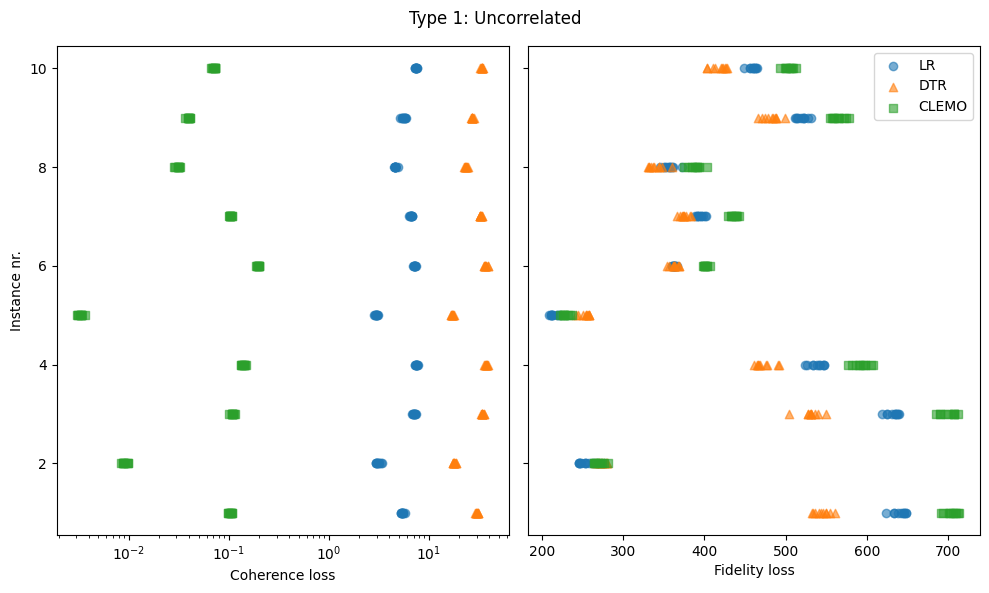

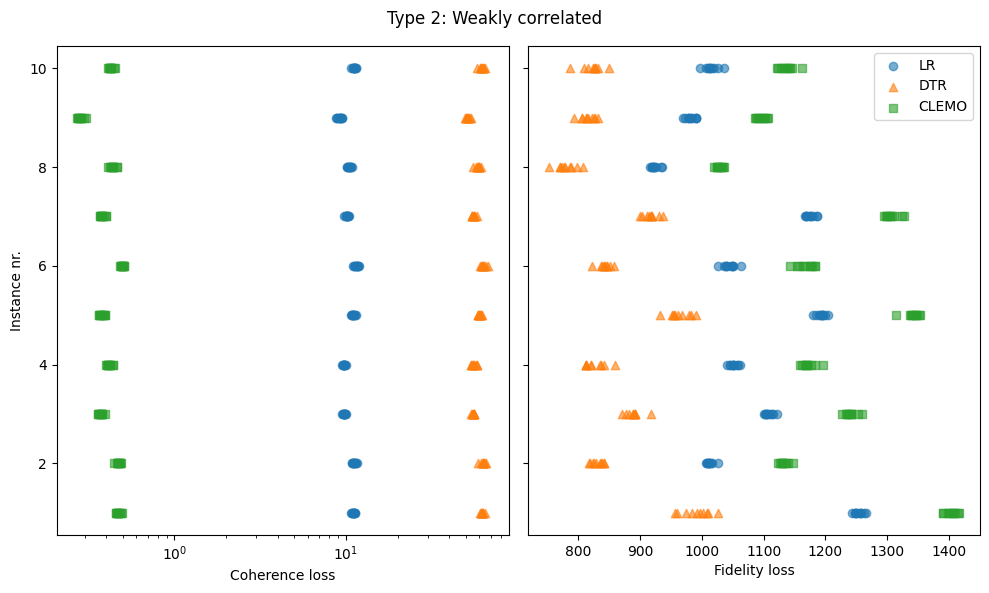

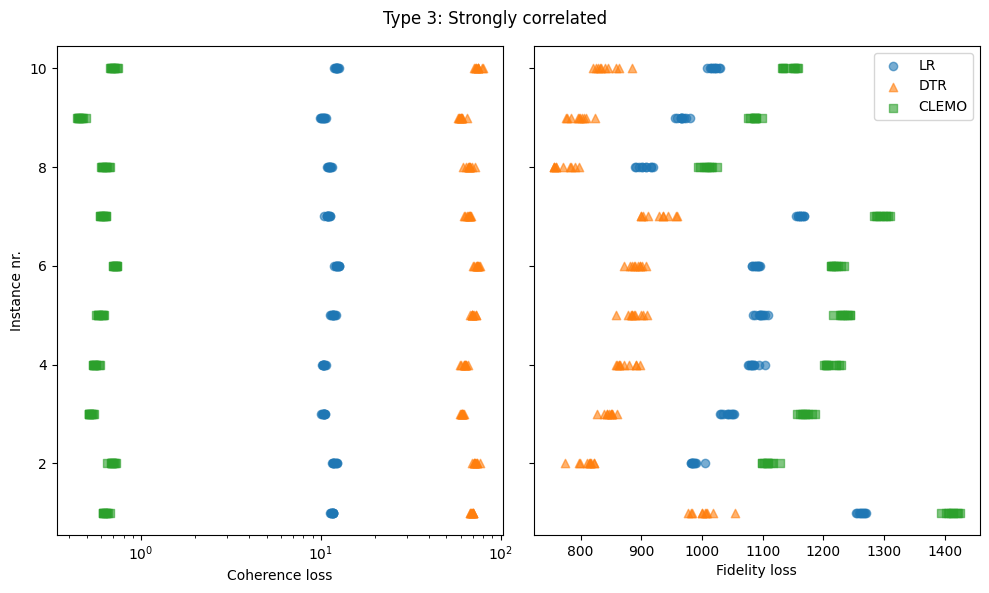

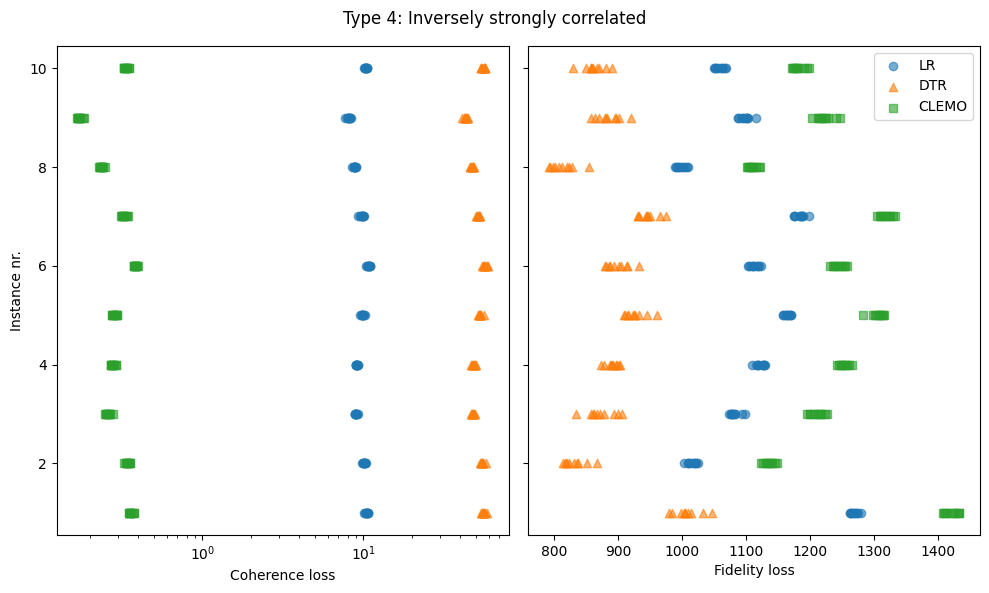

In [16]:
df['Total Incoherence'] = df['Error Objective'] + df['Error Constraint']

for t in range(4):
    df_type = df[df['Type nr'] == f'Type {t}']
    fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

    for method, marker in zip(['LR', 'DTR', 'CLEMO'], ['o', '^', 's']):
        df_m = df_type[df_type['Method'] == method]
        instance_idx = df_m['Instance nr'].str.replace('Instance ', '').astype(int) + 1
        axes[0].scatter(df_m['Total Incoherence'], instance_idx, label=method, marker=marker, alpha=0.6)
        axes[1].scatter(df_m['Error Prediction'], instance_idx, label=method, marker=marker, alpha=0.6)

    axes[0].set_xscale('log')
    axes[0].set_xlabel('Coherence loss')
    axes[0].set_ylabel('Instance nr.')
    axes[1].set_xlabel('Fidelity loss')
    axes[1].legend()

    fig.suptitle(f'Type {t + 1}: {type_names[t]}')
    plt.tight_layout()
    plt.show()
